In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import os, sys

PROJECT_PATH = "/content/drive/MyDrive/HydroTerra"
SRC_PATH = f"{PROJECT_PATH}/src"

os.makedirs(PROJECT_PATH, exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/src", exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/data", exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/outputs", exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/notebooks", exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/pygame_app", exist_ok=True)

# Make src/ importable
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

SIZE = 128

print("HydroTerra workspace ready!")

HydroTerra workspace ready!


In [4]:
!pip install noise -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.0/132.0 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [5]:
import importlib
import terrain
import simulation
import vulnerability

# Reload so Colab always uses the latest version
# saved in Google Drive.
importlib.reload(terrain)
importlib.reload(simulation)
importlib.reload(vulnerability)

# Import the functions we need
from terrain import generate_terrain, generate_random_terrain

from simulation import (
    add_rain,
    flow_water,
    erode_terrain,
    deposit_sediment,
    evaporate,
    simulation_step
)

from vulnerability import (
    normalize,
    calculate_risk,
    make_settlement
)

print("Latest HydroTerra modules loaded successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project exists: True
src exists: True

Files inside src:
['terrain.ipynb', '__pycache__', 'vulnerability.ipynb', 'simulation.ipynb', 'simulation.py', 'terrain.py', 'vulnerability.py']

src added to Python path: /content/drive/MyDrive/HydroTerra/src
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project exists: True
src exists: True

Files inside src:
['terrain.ipynb', '__pycache__', 'vulnerability.ipynb', 'simulation.ipynb', 'simulation.py', 'terrain.py', 'vulnerability.py']

src added to Python path: /content/drive/MyDrive/HydroTerra/src
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project exists: True
src exists: True

Files inside src:
['terrain.ipynb', '__pycache__', 'vulnerability.ipynb', 's

(128, 128)


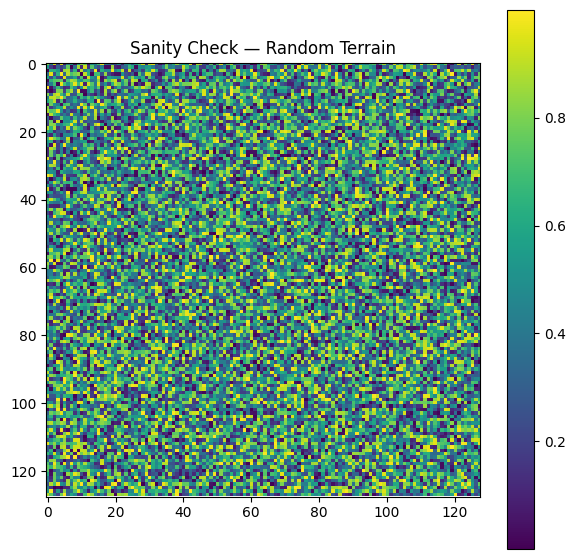

In [6]:
terrain_random = generate_random_terrain(SIZE)
print(terrain_random.shape)

plt.figure(figsize=(7, 7))
plt.imshow(terrain_random)
plt.colorbar()
plt.title("Sanity Check — Random Terrain")
plt.show()

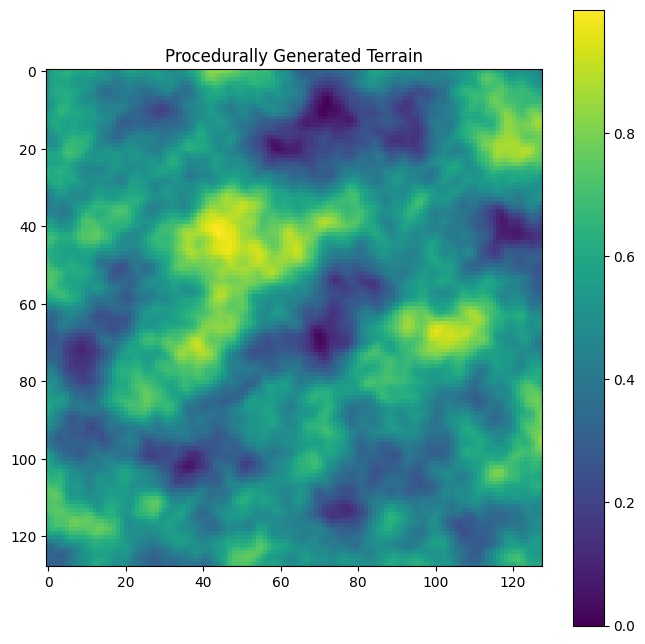

In [7]:
terrain_map = generate_terrain(size=SIZE)

plt.figure(figsize=(8, 8))
plt.imshow(terrain_map)
plt.colorbar()
plt.title("Procedurally Generated Terrain")
plt.show()

In [8]:
np.save(f"{PROJECT_PATH}/data/heightmap.npy", terrain_map)
print("Saved heightmap.npy")

Saved heightmap.npy


In [9]:
water = np.zeros_like(terrain_map)
sediment = np.zeros_like(terrain_map)

print("Terrain:", terrain_map.shape)
print("Water:", water.shape)
print("Sediment:", sediment.shape)

Terrain: (128, 128)
Water: (128, 128)
Sediment: (128, 128)


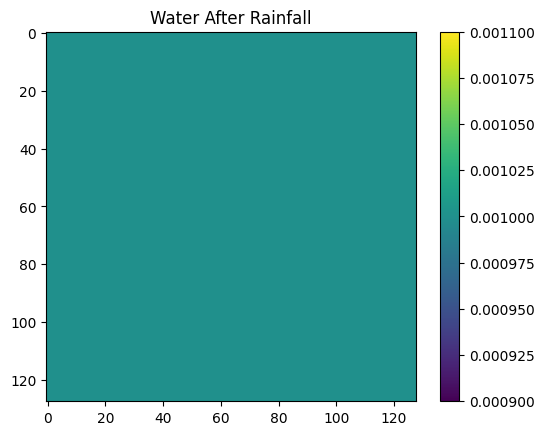

In [10]:
water = add_rain(water)

plt.imshow(water)
plt.colorbar()
plt.title("Water After Rainfall")
plt.show()

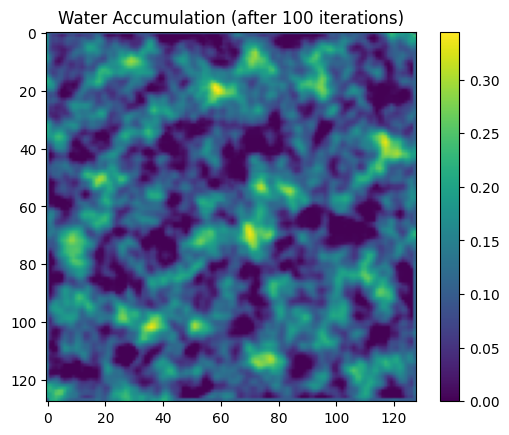

In [11]:
water = np.zeros((SIZE, SIZE))
for i in range(100):
    water = add_rain(water, 0.001)
    water = flow_water(terrain_map, water)

plt.imshow(water)
plt.colorbar()
plt.title("Water Accumulation (after 100 iterations)")
plt.show()

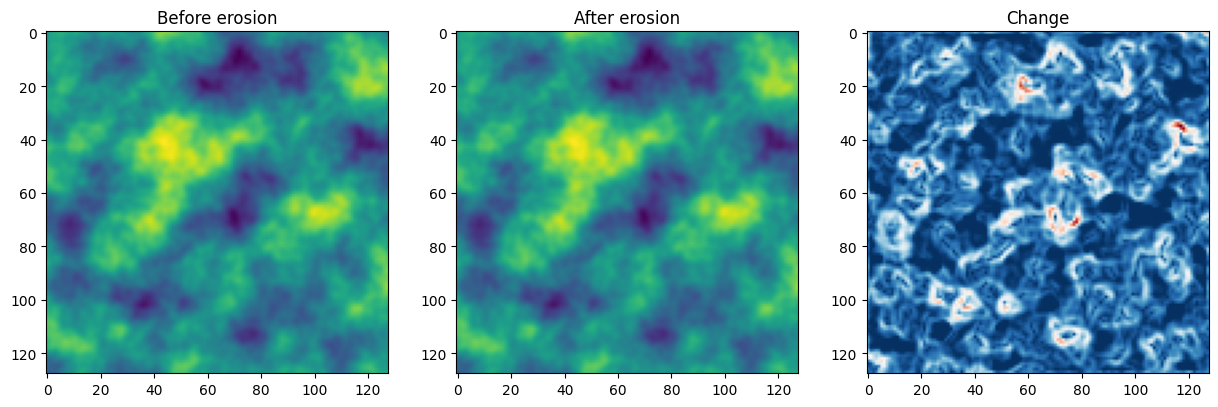

In [12]:
terrain_before = terrain_map.copy()
terrain_map, sediment = erode_terrain(terrain_map, water)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(terrain_before); axes[0].set_title("Before erosion")
axes[1].imshow(terrain_map); axes[1].set_title("After erosion")
axes[2].imshow(terrain_map - terrain_before, cmap="RdBu"); axes[2].set_title("Change")
plt.show()

In [13]:
terrain_map, sediment = deposit_sediment(terrain_map, water, sediment)
water = evaporate(water)
print("Sediment remaining:", sediment.sum())
print("Water range after evaporation:", water.min(), water.max())

Sediment remaining: 0.027184839152545465
Water range after evaporation: 0.0 0.3411856048636641


Completed 50/300 simulation steps
Completed 100/300 simulation steps
Completed 150/300 simulation steps
Completed 200/300 simulation steps
Completed 250/300 simulation steps
Completed 300/300 simulation steps


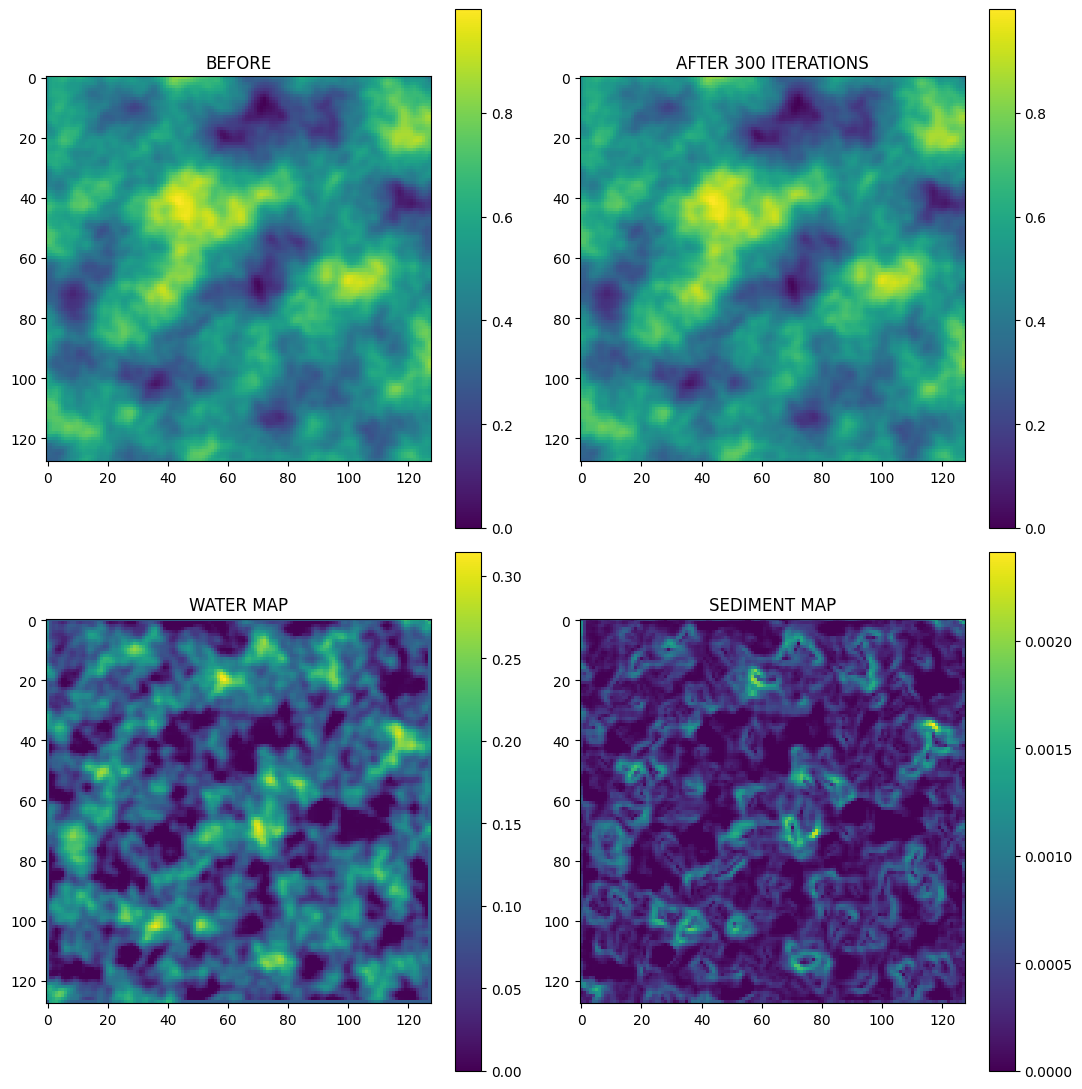

In [14]:
terrain_map = generate_terrain()
water = np.zeros_like(terrain_map)
sediment = np.zeros_like(terrain_map)
terrain_before = terrain_map.copy()

ITERATIONS = 300

for i in range(ITERATIONS):
    terrain_map, water, sediment = simulation_step(terrain_map, water, sediment)
    if (i + 1) % 50 == 0:
        print(f"Completed {i + 1}/{ITERATIONS} simulation steps")

fig, axes = plt.subplots(2, 2, figsize=(11, 11))
im0 = axes[0,0].imshow(terrain_before); axes[0,0].set_title("BEFORE"); plt.colorbar(im0, ax=axes[0,0])
im1 = axes[0,1].imshow(terrain_map); axes[0,1].set_title("AFTER 300 ITERATIONS"); plt.colorbar(im1, ax=axes[0,1])
im2 = axes[1,0].imshow(water); axes[1,0].set_title("WATER MAP"); plt.colorbar(im2, ax=axes[1,0])
im3 = axes[1,1].imshow(sediment); axes[1,1].set_title("SEDIMENT MAP"); plt.colorbar(im3, ax=axes[1,1])
plt.tight_layout()
plt.show()


# ============================================================
# FINAL FULL SIMULATION
# Start from a fresh terrain so earlier unit-style tests
# do not affect the final results.
# ============================================================

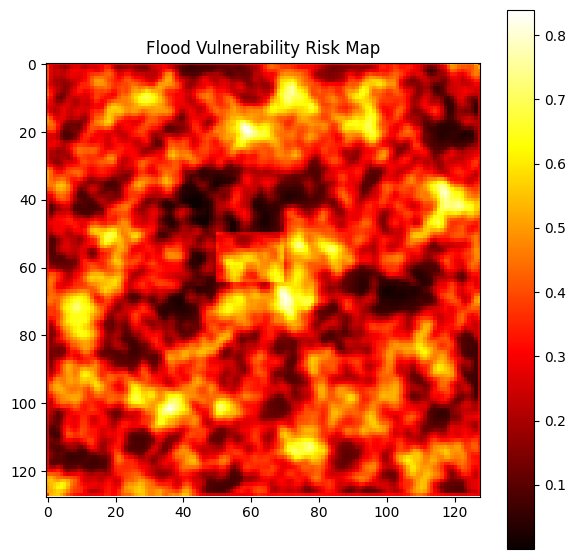

In [15]:
settlement = make_settlement(SIZE)
risk = calculate_risk(terrain_map, water, settlement)

plt.figure(figsize=(7, 7))
plt.imshow(risk, cmap="hot")
plt.colorbar()
plt.title("Flood Vulnerability Risk Map")
plt.show()

In [16]:
np.save(f"{PROJECT_PATH}/data/heightmap.npy", terrain_map)
np.save(f"{PROJECT_PATH}/data/water.npy", water)
np.save(f"{PROJECT_PATH}/data/sediment.npy", sediment)
np.save(f"{PROJECT_PATH}/data/risk.npy", risk)
np.save(f"{PROJECT_PATH}/data/settlement.npy", settlement)

print("All arrays saved to Drive — teammate can now load them in Pygame.")

All arrays saved to Drive — teammate can now load them in Pygame.
